### Robin Kemmerich, 30.09.2022 - angepasst von Judith Bütefür & Niklas Küper, 24.10.2022
#### Overview of code used for EEG oddball classification. These are just code examples that can be integrated.

In [2]:
import mne
import os
import numpy as np
import matplotlib.pyplot as plt

from mne.decoding import Vectorizer, cross_val_multiscore, SlidingEstimator, Scaler
from mne.io import read_raw_brainvision, concatenate_raws

import xlsxwriter

from sklearn.svm import SVC
from mne.preprocessing import Xdawn
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import balanced_accuracy_score, confusion_matrix

##### Standard version

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.2 - 4 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.20
- Lower transition bandwidth: 0.20 Hz (-6 dB cutoff frequency: 0.10 Hz)
- Upper passband edge: 4.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 5.00 Hz)
- Filter length: 16501 samples (16.501 sec)

Used Annotations descriptions: ['New Segment/', 'Response/R125', 'Response/R127', 'Stimulus/S  1', 'Stimulus/S  2', 'Stimulus/S  3', 'Stimulus/S  5', 'Stimulus/S  8', 'Stimulus/S  9', 'Stimulus/S 16', 'Stimulus/S 17']
number of standard stimuli: 742
number of deviant stimuli: 103
Not setting metadata
845 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 845 events and

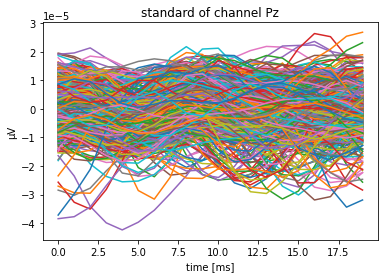

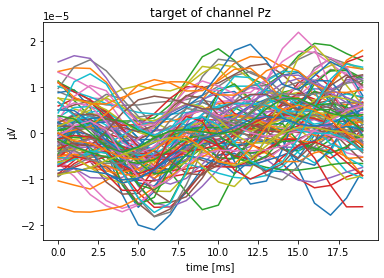

Not setting metadata
845 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 845 events and 901 original time points ...
0 bad epochs dropped


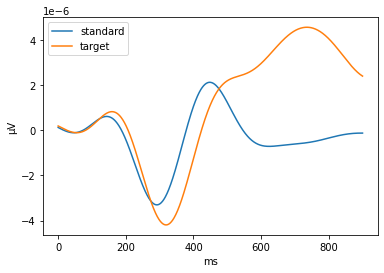

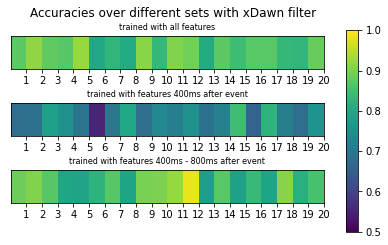

0.8618001930501931
0.7205678893178894
0.8538529601029602


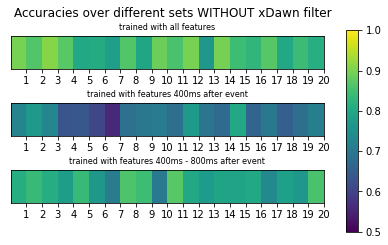

0.8439913127413128
0.6883848133848134
0.7957287644787644


In [10]:
# define machine learning classifier
clf = make_pipeline(Xdawn(n_components=8), Vectorizer(), StandardScaler(), SVC(kernel="linear")) # can also use MinMaxScaler() depending on purpose
clf_2 = make_pipeline(Vectorizer(), StandardScaler(), SVC(kernel="linear"))
cv = StratifiedShuffleSplit(n_splits=20, test_size = 0.2, random_state=42)
def getFileList(p='.',e='',d='/',fl=[]):

    """p=path, e=extension, d=path-delimiter, fl=recursive filelist"""

    for f in os.listdir(p):
        f=p+d+f
        if os.path.isdir(f):
            fl=getFileList(f,e,d,fl)
        elif os.path.isfile(f) and f.endswith(e):
            fl.append(f)
    return fl

files = getFileList(p='W:\measures\EEG Daten_NE\IEEE_Final\EEG', e='.vhdr', d='/', fl=[])
# files = getFileList(p='Z:\\user\\mitarbeiter\\judith\\1_Lehre\\Neuroengineering\\WS22_23\\Uebungen\\files', e='.vhdr', d='/', fl=[])

# for file in files:
for i in range(5,6):
    data_path = files[i]
    raw = read_raw_brainvision(data_path, preload=True, verbose=False)
      
    # bandpass filter
    raw.filter(0.2,4.0)

    # extract events
    events, event_dict = mne.events_from_annotations(raw)
    events = mne.pick_events(events, include=[1, 2])  # trigger 1 = standard // 2 = target
    
    # number of standards and targets
    standard_n = np.count_nonzero(events == 1, axis=1)
    print("number of standard stimuli:",(standard_n == 1).sum())
    target_n = np.count_nonzero(events == 2, axis=1)
    print("number of deviant stimuli:",(target_n == 1).sum())
    
    # define epochs   
    epochs_1 = mne.Epochs(raw, events, tmin=-0.01, tmax=0.8, baseline=None, preload=True, detrend=None)  # tmin: Start der Daten 200ms VOR Event, tmax: Stopp der Daten 600ms NACH Event
    epochs_2 = mne.Epochs(raw, events, tmin=-0.0, tmax=0.4, baseline=None, preload=True, detrend=None)
    epochs_3 = mne.Epochs(raw, events, tmin=0.4, tmax=0.8, baseline=None, preload=True, detrend=None)

    # downsampling
    epochs_1.resample(25)
    epochs_2.resample(25)
    epochs_3.resample(25)

    # machine learning - all data with xDawn filter
    X_1 = epochs_1.get_data()
    labels = epochs_1.events[:, 2]
    
    scores_1 = []
    target_names = ["standard", "target"]
    for train, test in cv.split(epochs_1, labels):
        preds = np.empty(len(labels))
        clf.fit(epochs_1[train], labels[train])
        preds[test] = clf.predict(epochs_1[test])
        scores_1.append(balanced_accuracy_score(labels[test], preds[test]))    
    
    # machine learning - first 400ms after event with xDawn filter
    X_2 = epochs_2.get_data()
    labels_2 = epochs_2.events[:, 2]
    
    scores_2 = []
    for train, test in cv.split(epochs_2, labels_2):
        preds_2 = np.empty(len(labels_2))
        clf.fit(epochs_2[train], labels_2[train])
        preds_2[test] = clf.predict(epochs_2[test])
        scores_2.append(balanced_accuracy_score(labels_2[test], preds_2[test]))  

    # machine learning - 400ms - 800ms after event with xDawn filter
    X_3 = epochs_3.get_data()
    labels_3 = epochs_3.events[:, 2]
    
    scores_3 = []
    for train, test in cv.split(epochs_3, labels_3):
        preds_3 = np.empty(len(labels_3))
        clf.fit(epochs_3[train], labels_3[train])
        preds_3[test] = clf.predict(epochs_3[test])
        scores_3.append(balanced_accuracy_score(labels_3[test], preds_3[test]))  

    # machine learning - all data WITHOUT xDawn filter
    X_1 = epochs_1.get_data()
    labels = epochs_1.events[:, 2]
    
    scores_4 = []
    target_names = ["standard", "target"]
    for train, test in cv.split(epochs_1, labels):
        preds_4 = np.empty(len(labels))
        clf_2.fit(epochs_1[train], labels[train])
        preds_4[test] = clf_2.predict(epochs_1[test])
        scores_4.append(balanced_accuracy_score(labels[test], preds_4[test]))    
    
    # machine learning - first 400ms after event WITHOUT xDawn filter
    X_2 = epochs_2.get_data()
    labels_2 = epochs_2.events[:, 2]
    
    scores_5 = []
    for train, test in cv.split(epochs_2, labels_2):
        preds_5 = np.empty(len(labels_2))
        clf_2.fit(epochs_2[train], labels_2[train])
        preds_5[test] = clf_2.predict(epochs_2[test])
        scores_5.append(balanced_accuracy_score(labels_2[test], preds_5[test]))  

    # machine learning - 400ms - 800ms after event WITHOUT xDawn filter
    X_3 = epochs_3.get_data()
    labels_3 = epochs_3.events[:, 2]
    
    scores_6 = []
    for train, test in cv.split(epochs_3, labels_3):
        preds_6 = np.empty(len(labels_3))
        clf_2.fit(epochs_3[train], labels_3[train])
        preds_6[test] = clf_2.predict(epochs_3[test])
        scores_6.append(balanced_accuracy_score(labels_3[test], preds_6[test]))  


    # Plotten aller einzelnen Epochen in einem Fenster, sortiert nach Standard/Target
    plt.figure()
    for i in range(0,len(labels)):
        if labels[i] == 1:
            plt.plot(X_1[i,24,:])   # Pz
            plt.xlabel("time [ms]")
            plt.ylabel("µV")
            plt.title("standard of channel Pz")
    plt.show()

    plt.figure()
    for j in range(0,len(labels)):
        if labels[j] == 2:
            plt.plot(X_1[j,24,:])   # Pz
            plt.xlabel("time [ms]")
            plt.ylabel("µV")
            plt.title("target of channel Pz")
    plt.show()

    # Plotten des Verlaufs der Epochen nach Averaging
    epochs_plt = mne.Epochs(raw, events, tmin=-0.1, tmax=0.8, baseline=(-0.1,0), preload=True, detrend=None)  # tmin: Start der Daten 100ms VOR Event, tmax: Stopp der Daten 600ms NACH Event
    epochs_ave = epochs_plt.average(picks=24, method='mean', by_event_type=True)

    plt.figure()
    plt.plot(epochs_ave[0].data.transpose(), label='standard')
    plt.plot(epochs_ave[1].data.transpose(), label='target')
    plt.legend()
    plt.xlabel('ms')
    plt.ylabel('µV')
    plt.show()


    #Plotten der machine Learning Ergebnisse 
    fig, (ax0, ax1, ax2) = plt.subplots(3, 1)
    c = ax0.pcolormesh([scores_1], vmin=0.5, vmax=1.0)
    ax0.set_title('trained with all features', fontsize=8)
    # ax0.set_xlabel('Sets', fontsize=8)
    ax0.set_xticks([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20], fontsize=4)
    ax0.set_yticks([])
    c = ax1.pcolormesh([scores_2], vmin=0.5, vmax=1.0)
    ax1.set_title('trained with features 400ms after event', fontsize=8)
    # ax1.set_xlabel('Sets', fontsize=8)
    ax1.set_xticks([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20], fontsize=4)
    ax1.set_yticks([])
    c = ax2.pcolormesh([scores_3], vmin=0.5, vmax=1.0)
    ax2.set_title('trained with features 400ms - 800ms after event', fontsize=8)
    # ax2.set_xlabel('Sets', fontsize=8)
    ax2.set_xticks([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20], fontsize=4)
    ax2.set_yticks([])
    
    fig.subplots_adjust(right=0.85)
    cbar_ax = fig.add_axes([0.9, 0.2, 0.03, 0.7])
    fig.colorbar(c, cax=cbar_ax)
    fig.suptitle('Accuracies over different sets with xDawn filter')
    plt.subplots_adjust(bottom=0.3, 
                    top=0.88, 
                    wspace=0.1, 
                    hspace=1.0)
    plt.show()

    print(np.mean(scores_1))
    print(np.mean(scores_2))
    print(np.mean(scores_3))

    ### Plotten der machine Learning Ergebnisse OHNE xDawn ###
    fig, (ax0, ax1, ax2) = plt.subplots(3, 1)
    c = ax0.pcolormesh([scores_4], vmin=0.5, vmax=1.0)
    ax0.set_title('trained with all features', fontsize=8)
    # ax0.set_xlabel('Sets', fontsize=8)
    ax0.set_xticks([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20], fontsize=4)
    ax0.set_yticks([])
    c = ax1.pcolormesh([scores_5], vmin=0.5, vmax=1.0)
    ax1.set_title('trained with features 400ms after event', fontsize=8)
    # ax1.set_xlabel('Sets', fontsize=8)
    ax1.set_xticks([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20], fontsize=4)
    ax1.set_yticks([])
    c = ax2.pcolormesh([scores_6], vmin=0.5, vmax=1.0)
    ax2.set_title('trained with features 400ms - 800ms after event', fontsize=8)
    # ax2.set_xlabel('Sets', fontsize=8)
    ax2.set_xticks([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20], fontsize=4)
    ax2.set_yticks([])
    
    fig.subplots_adjust(right=0.85)
    cbar_ax = fig.add_axes([0.9, 0.2, 0.03, 0.7])
    fig.colorbar(c, cax=cbar_ax)
    fig.suptitle('Accuracies over different sets WITHOUT xDawn filter')
    plt.subplots_adjust(bottom=0.3, 
                    top=0.88, 
                    wspace=0.1, 
                    hspace=1.0)
    plt.show()

    print(np.mean(scores_4))
    print(np.mean(scores_5))
    print(np.mean(scores_6))


##### Subsampling in case equal number in both classes is wanted

In [ ]:
for j in range(50):

    # define epochs with undersampling
    random_standard_indices = np.random.choice(standard_indices, target_n, replace=False)
    under_sample_indices = np.concatenate([random_standard_indices, target_indices])

    epochs_iteration = epochs_1[under_sample_indices]
    y = epochs_iteration.events[:, 2]

    for train, test in cv.split(epochs_iteration, y):
        preds = np.empty(len(y))
        clf.fit(epochs_iteration[train], y[train])
        preds[test] = clf.predict(epochs_iteration[test])
        scores_1.append(balanced_accuracy_score(y[test], preds[test]))

##### Visualizing xDawn filters (Topoplots)

In [ ]:
def visualize(epochs):
    # adapted from https://mne.tools/dev/auto_examples/decoding/decoding_xdawn_eeg.html

    fig, axes = plt.subplots(nrows=len(event_id), ncols=n_filter,
                             figsize=(n_filter, len(event_id) * 2))
    fitted_xdawn = clf.steps[0][1]
    info = create_info(epochs.ch_names, 1, epochs.get_channel_types())
    info.set_montage(epochs.get_montage())
    for ii, cur_class in enumerate(sorted(event_id)):
        cur_patterns = fitted_xdawn.patterns_[cur_class]
        pattern_evoked = EvokedArray(cur_patterns[:n_filter].T, info, tmin=0)
        pattern_evoked.plot_topomap(
            times=np.arange(n_filter),
            time_format='Component %d' if ii == 0 else '', colorbar=False,
            show_names=False, axes=axes[ii], show=False)
        axes[ii, 0].set(ylabel=cur_class)

    fig.tight_layout(h_pad=1.0, w_pad=1.0, pad=0.1)
    plt.rcParams["figure.figsize"] = (30,10)
    plt.show()